# Reflectance and transmittance using the Green's function's method (Propagation of a short laser pulse in a plasma - B.Nodland)

For an incident wave $E_{I}(t,0) = \exp(-\omega_{e}^{2} t^{2})\cos(\omega_{c}t)$ that encounters a plasma we have that:

* For the reflected wave $\displaystyle E_{R}(t,0) = \int_{-\infty}^{\infty} E_{I}(t',0)R(t-t')dt´$ where $R= -(2/t)J_{2}(t)H(t)$
  
* For the transmitted pulse $\displaystyle E_{T}(t,x) = \int_{-\infty}^{\infty} E_{I}(t',0) \Gamma_{T}(t-t',x)$,

  where $\Gamma_{T}(t,x) =  -\frac{xt}{t+x}J_{0}(t^{2}-x^{2}) + \left( \frac{xt}{t+x} + \frac{2(t-x)}{(t+x)^{2}} \right)\times J_{2}(t^{2}-x^{2})$

But we program the transmittance in a better way as the convolution is commmutative.

In Laplace space $\bar{E}_{T}(t,x) = \bar{E}_{I}(t,0) \times \bar{\Gamma}_{T} = \bar{E}_{I}(t,0) \times \bar{T}\times \bar{G}_{T}$

but as $\bar{E}_{T}(t,0) = \bar{E}_{I}(t,0) \times \bar{T}$ then  $\bar{E}_{T}(t,x) = \bar{E}_{T}(t,0) \times \bar{G}_{T}$

So using equation (3) $E_{I}(t,0)+E_{R}(t,0) = E_{I}(t,0)$ after obtaining the reflected electric field then we just make use of the 
transmittance Green's function to propagate it by a convolution:

* $E_{T}(t,x) = \int_{-\infty}^{+\infty} E_{T}(t',0)G_{T}(t-t´)dt'$

* where $G_{T}(t,x) = \delta(t-x) - x \frac{J_{1}[(\sqrt{t^{2}-x^{2}})]}{\sqrt{t^{2}-x^{2}}}H(t-x) $

/var/folders/r1/8fnw2qyd6vs6x4fvg2cghqzh0000gn/T/ipykernel_4826/2015075369.py:141: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  wake_integral = np.trapz(E_T_b_prime * kernel, t_prime)


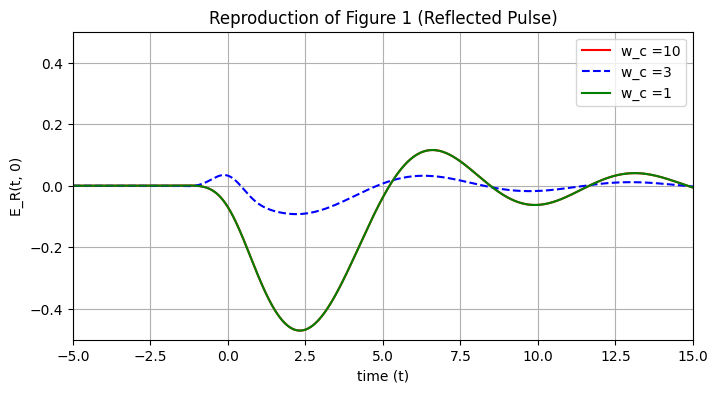

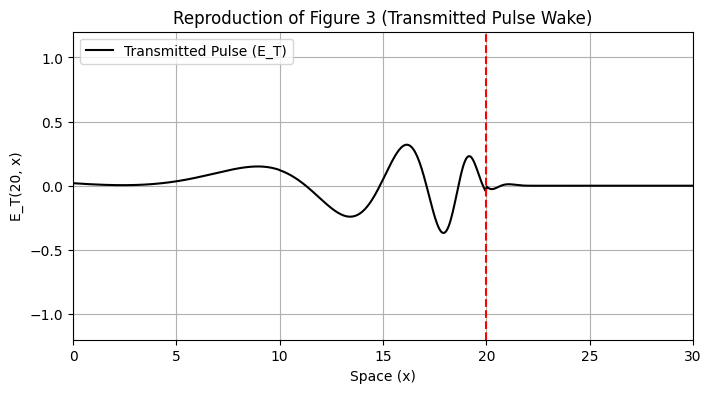

"\n#Envelope\n\nfrom scipy.signal import hilbert\n\n# 1. Calculamos la señal analítica (compleja) con Hilbert\nseñal_analitica_incidente = hilbert(E_I_punteada)\nseñal_analitica_transmitida = hilbert(E_T_x)\n\n# 2. La envolvente es simplemente el valor absoluto (la magnitud)\nenvolvente_incidente = np.abs(señal_analitica_incidente)\nenvolvente_transmitida = np.abs(señal_analitica_transmitida)\n\n# --- PLOT DE LAS ENVOLVENTES ---\nplt.figure(figsize=(8, 4))\nplt.plot(x_vals, envolvente_transmitida, 'k-', linewidth=2, label='Envelope Transmitted ($v_g < c$)')\nplt.plot(x_vals, envolvente_incidente, 'k--', linewidth=2, label='Envelope Incident ($v_g = c$)')\n\n# Graficamos también las oscilaciones originales pero muy claritas (alfa=0.3) para referencia\nplt.plot(x_vals, E_T_x, 'k-', alpha=0.3)\nplt.plot(x_vals, E_I_punteada, 'k--', alpha=0.3)\n\nplt.axvline(x=20, color='red', linestyle=':', label='x=20 (Vacuum Peak)')\nplt.xlim(15, 23)\nplt.ylim(0, 1.2)\nplt.xlabel('Space (x)')\nplt.ylabe

In [3]:
#This is a script that obtains the reflection and transmission for a laser pulse that interacts with a plasma mirror
#Using the Greens functions method we only obtain at boundary the reflected and transmitted and propagate them




"""
================================================================================
CODE ARCHITECTURE AND PHYSICAL INTERPRETATION SUMMARY
================================================================================

1. THE TIME ARRAYS AND CAUSALITY:
- t_hist (acts as t'): The chronological time at the boundary (x=0). We start at 
  a negative value (e.g., -25) to allow the Gaussian envelope of the laser to arrive 
  smoothly. Starting at t=0 would artificially chop the pulse and create a numerical shock.
- t_R (acts as t - t'): The delay time. It represents the time elapsed *since* a specific impulse hit the plasma.
  It is strictly positive to structurally 
  enforce the Heaviside step function H(t), preserving causality (the plasma 
  cannot ring before it is struck).

2. THE CONVOLUTION AND INTERPOLATION (BOUNDARY CONDITIONS):
- We use mode='full' for the convolution because the plasma has inertia. It 
  continues to "ring" (echo) long after the incident pulse has passed. The 'full' 
  array captures the complete lifetime of this physical excitation.
- We then use np.interp to sample this extended response back onto our original 
  observation window (t_hist). This aligns both the incident and reflected fields 
  on the exact same temporal grid, allowing us to compute the boundary condition 
  E_T(t,0) = E_I(t,0) + E_R(t,0) (Eq. 3) through strict element-wise addition.

3. RETARDED TIME AND DIRECT PROPAGATION:
- t_delayed = t_fixed - x: Since light travels at c=1, the electromagnetic 
  information we observe at position 'x' at time 't_fixed' actually crossed the 
  boundary in the past. 
- The direct term (Dirac delta in Green's function) is evaluated by simply 
  looking up what the boundary field E_T_boundary was exactly at 't_delayed'.

4. THE WAKE INTEGRAL (DISPERSIVE PROPAGATION):
- The boolean mask (t_hist < t_delayed) enforces spatial causality. It truncates 
  our integration arrays to include only the light that has actually had enough 
  time to reach the coordinate 'x'.
- Numerical safeguard: When the delay time exactly equals the travel distance 
  (t-t' = x), the argument of the Bessel function becomes zero. To avoid a 0/0 
  division error, we apply L'Hôpital's limit mathematically: lim(z->0) J_1(z)/z = 0.5.
- The total transmitted field is the direct unperturbed wave MINUS the wake 
  integral, representing the dispersive phase shift and amplitude modulation 
  caused by the plasma electrons.
"""


import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt

# --- PARAMETERS  ---
w_e = 1.0       # Intermediate Pulse (Intermediate Duration)
w_c = 1.0       # Carrier Frequency (Intermediate Frequency)
w_c2 = 3.0
w_c3 = 1.0
t_fixed = 20.0  # Time for evaluation (paper)
dt = 0.005       # Time resolution for integral

# 1. Boundary story (x=0) it represents t' in Greens function
t_hist = np.arange(-25, 25, dt)


# Incident field E_I (Ec. 21)
E_I = np.exp(-w_e**2 * t_hist**2) * np.cos(w_c * t_hist)




# Reflected field E_R (Ec. 23)
t_R = np.arange(0, 35, dt) #This represents t-t', its the time after the field hit the plasma it makes Heaviside unnecessary
R = np.zeros_like(t_R)
R[1:] = -(2.0 / t_R[1:]) * sp.jv(2, t_R[1:]) #Contains bessel j_2, note that j_2/t as t->0 is zero so no prob R[0]=0


# Convolution to obtain the reflected field
E_R_full = np.convolve(E_I, R, mode='full') * dt
t_full = t_hist[0] + t_R[0] + np.arange(len(E_R_full)) * dt
E_R = np.interp(t_hist, t_full, E_R_full)

#For reproducing plot 3 exactly with all the reflectances
E_I2 = np.exp(-w_e**2 * t_hist**2) * np.cos(w_c2 * t_hist)
E_I3 = np.exp(-w_e**2 * t_hist**2) * np.cos(w_c3 * t_hist)
E_R_full2 = np.convolve(E_I2, R, mode='full') * dt
E_R_full3 = np.convolve(E_I3, R, mode='full') * dt


"""
Nuestro t-t' (que es t_R) mide hasta cuando nuestro sistema "se calma" pero en si es hasta cuando nosotros queremos
medir la respuesta del sistema. Como la onda de agua despues del golpe, t-t' mide hasta cuando nos interesa a nosotros verla.

La convolución es justo toda la respuesta del sistema desde que entra la fuente a interactuar con él hasta
que se calma (nuestro t-t' maximo). Entonces en el máximo de t_hist (que funge como t')
es como el último golpe que genera un impulso y por ende tarda t-t' max en calmarse sumandose los arrays.

Ahora nosotros interpolamos en t_hist porque solo nos interesa el tiempo que interactuó con el laser,
en t_hist max ya no hay más impulso por lo que no nos interesa el t-t' max sino cuanto se reflejó y se transmitió hasta ese momento 

"""

# Transmitted field at boundary (Ec. 3)
E_T_boundary = E_I + E_R

# 2. Space propagation (x > 0)
x_vals = np.linspace(0, 50, 1000) 
E_T_x = np.zeros_like(x_vals)    
E_I_punteada = np.zeros_like(x_vals) # Reference dotted line

# We obtain the field for every x
for i, x in enumerate(x_vals): #enumerate allows us to have an index i and its respective value x of x_vals
    # Tiempo retardado: momento exacto en que la parte frontal llega a 'x'
    t_delayed = t_fixed - x
    
    # --- TÉRMINO 1: Direct propagation (Dirac delta) ---
    # It is simply the field that entered at x=0 evaluated at the delayed time.
    E_direct = np.interp(t_delayed, t_hist, E_T_boundary)
    
    # Dotted field (just incident)
    E_I_punteada[i] = np.interp(t_delayed, t_hist, E_I)
    
    # --- TÉRMINO 2: Wake (La integral de la Ec. 29) ---
    # We filter only the times (t') that already had time to reach 'x'.
    mask = t_hist < t_delayed
    t_prime = t_hist[mask]
    E_T_b_prime = E_T_boundary[mask]
    
    if len(t_prime) > 0 and t_prime[-1] < t_delayed:
        # delta_t es (t - t') en la Ec. 29
        delta_t = t_fixed - t_prime
        arg = np.sqrt(delta_t**2 - x**2)
        
        # Kernel of integración (OJO! evitando división por 0 cuando arg -> 0)
        kernel = np.zeros_like(arg)
        valid = arg > 1e-8
        kernel[valid] = x * sp.jv(1, arg[valid]) / arg[valid]
        kernel[~valid] = x * 0.5  # Límite de J1(z)/z es 0.5 cuando z->0
        
        # Numerical Integration
        wake_integral = np.trapz(E_T_b_prime * kernel, t_prime)
    else:
        wake_integral = 0.0
        
    # The total field is the direct part MINUS the wake (the '-' sign comes from Ec 29).
    E_T_x[i] = E_direct - wake_integral


"""
# --- 3. PLOT  ---
#Reflectance
plt.figure(figsize=(8, 4))
plt.plot(t_hist, E_T_boundary, 'r-', label='w_c =10')
plt.xlim(-5, 15)
plt.ylim(-1, 1)
plt.xlabel('time (t)')
plt.ylabel('E_T(t, 0)')
plt.title('Reproduction of Figure 1 (Trans Pulse at boundary)')
plt.legend()
plt.grid(True)
plt.show()
"""



# --- 3. PLOT  ---
#Reflectance
plt.figure(figsize=(8, 4))
plt.plot(t_full, E_R_full, 'r-', label='w_c =10')
plt.plot(t_full, E_R_full2, 'b--', label='w_c =3')
plt.plot(t_full, E_R_full3, 'g-', label='w_c =1')
plt.xlim(-5, 15)
plt.ylim(-0.5, 0.5)
plt.xlabel('time (t)')
plt.ylabel('E_R(t, 0)')
plt.title('Reproduction of Figure 1 (Reflected Pulse)')
plt.legend()
plt.grid(True)
plt.show()


#Transmission
plt.figure(figsize=(8, 4))
plt.plot(x_vals, E_T_x, 'k-', label='Transmitted Pulse (E_T)')
#plt.plot(x_vals, E_I_punteada, 'k--', label='Incident Pulse (Reference)')
plt.xlim(0, 30)
plt.ylim(-1.2, 1.2)
#plt.axvline(x=20, color='red', linestyle='--') # 
plt.xlabel('Space (x)')
plt.ylabel('E_T(20, x)')
plt.title('Reproduction of Figure 3 (Transmitted Pulse Wake)')
plt.legend()
plt.grid(True)
plt.show()

"""
#Envelope

from scipy.signal import hilbert

# 1. Calculamos la señal analítica (compleja) con Hilbert
señal_analitica_incidente = hilbert(E_I_punteada)
señal_analitica_transmitida = hilbert(E_T_x)

# 2. La envolvente es simplemente el valor absoluto (la magnitud)
envolvente_incidente = np.abs(señal_analitica_incidente)
envolvente_transmitida = np.abs(señal_analitica_transmitida)

# --- PLOT DE LAS ENVOLVENTES ---
plt.figure(figsize=(8, 4))
plt.plot(x_vals, envolvente_transmitida, 'k-', linewidth=2, label='Envelope Transmitted ($v_g < c$)')
plt.plot(x_vals, envolvente_incidente, 'k--', linewidth=2, label='Envelope Incident ($v_g = c$)')

# Graficamos también las oscilaciones originales pero muy claritas (alfa=0.3) para referencia
plt.plot(x_vals, E_T_x, 'k-', alpha=0.3)
plt.plot(x_vals, E_I_punteada, 'k--', alpha=0.3)

plt.axvline(x=20, color='red', linestyle=':', label='x=20 (Vacuum Peak)')
plt.xlim(15, 23)
plt.ylim(0, 1.2)
plt.xlabel('Space (x)')
plt.ylabel('Amplitude Envelope')
plt.title('Group Velocity Delay (Envelope Shift)')
plt.legend()
plt.grid(True)
plt.show()

"""



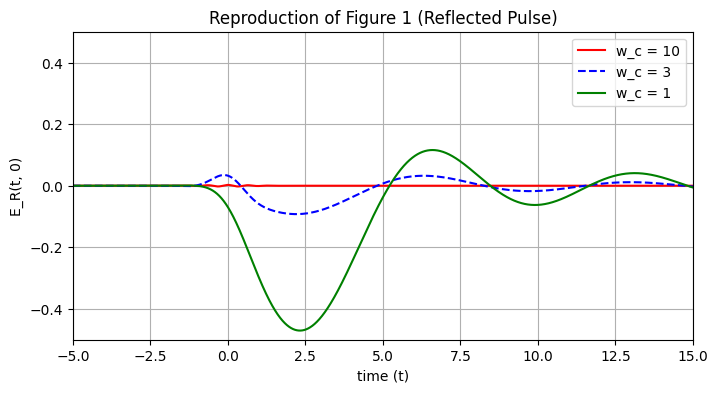

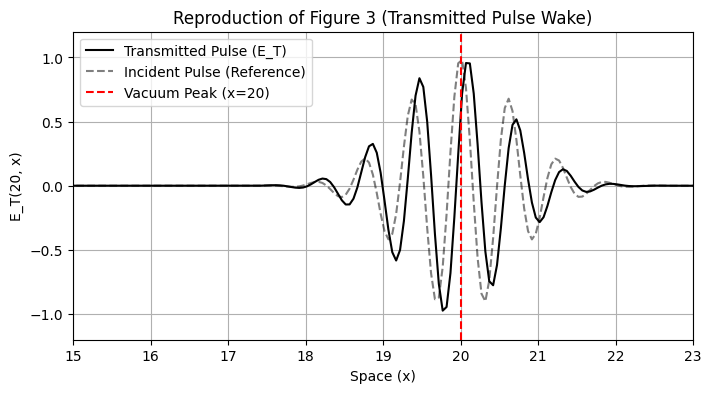

In [6]:
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt

# --- PARAMETERS  ---
w_e = 1.0       # Intermediate Pulse (Intermediate Duration)
w_c = 10.0      # CORREGIDO: Carrier Frequency = 10 (High Frequency)
w_c2 = 3.0      # Intermediate Frequency
w_c3 = 1.0      # Low Frequency
t_fixed = 20.0  # Time for evaluation (paper)
dt = 0.005      # Time resolution for integral

# 1. Boundary story (x=0) it represents t' in Greens function
t_hist = np.arange(-25, 25, dt)

# Incident field E_I 
E_I = np.exp(-w_e**2 * t_hist**2) * np.cos(w_c * t_hist)

# Reflected field E_R 
t_R = np.arange(0, 35, dt) 
R = np.zeros_like(t_R)
R[1:] = -(2.0 / t_R[1:]) * sp.jv(2, t_R[1:]) 

# Convolution to obtain the reflected field
E_R_full = np.convolve(E_I, R, mode='full') * dt
t_full = t_hist[0] + t_R[0] + np.arange(len(E_R_full)) * dt
E_R = np.interp(t_hist, t_full, E_R_full)

# For reproducing plot 1 exactly with all the reflectances
E_I2 = np.exp(-w_e**2 * t_hist**2) * np.cos(w_c2 * t_hist)
E_I3 = np.exp(-w_e**2 * t_hist**2) * np.cos(w_c3 * t_hist)
E_R_full2 = np.convolve(E_I2, R, mode='full') * dt
E_R_full3 = np.convolve(E_I3, R, mode='full') * dt

# Transmitted field at boundary (Ec. 3)
E_T_boundary = E_I + E_R

# 2. Space propagation (x > 0)
x_vals = np.linspace(0, 50, 1000) 
E_T_x = np.zeros_like(x_vals)    
E_I_punteada = np.zeros_like(x_vals) # Reference dotted line

# We obtain the field for every x
for i, x in enumerate(x_vals): 
    # Tiempo retardado
    t_delayed = t_fixed - x
    
    # --- TÉRMINO 1: Direct propagation (Dirac delta) ---
    E_direct = np.interp(t_delayed, t_hist, E_T_boundary)
    
    # Dotted field (just incident)
    E_I_punteada[i] = np.interp(t_delayed, t_hist, E_I)
    
    # --- TÉRMINO 2: Wake ---
    mask = t_hist < t_delayed
    t_prime = t_hist[mask]
    E_T_b_prime = E_T_boundary[mask]
    
    if len(t_prime) > 0 and t_prime[-1] < t_delayed:
        delta_t = t_fixed - t_prime
        arg = np.sqrt(delta_t**2 - x**2)
        
        kernel = np.zeros_like(arg)
        valid = arg > 1e-8
        kernel[valid] = x * sp.jv(1, arg[valid]) / arg[valid]
        kernel[~valid] = x * 0.5  
        
        # CORREGIDO: np.trapezoid en lugar de np.trapz para evitar el Deprecation Warning
        wake_integral = np.trapezoid(E_T_b_prime * kernel, t_prime)
    else:
        wake_integral = 0.0
        
    E_T_x[i] = E_direct - wake_integral

# --- 3. PLOTS  ---

# Figure 1: Reflectance
plt.figure(figsize=(8, 4))
plt.plot(t_full, E_R_full, 'r-', label='w_c = 10')
plt.plot(t_full, E_R_full2, 'b--', label='w_c = 3')
plt.plot(t_full, E_R_full3, 'g-', label='w_c = 1')
plt.xlim(-5, 15)
plt.ylim(-0.5, 0.5)
plt.xlabel('time (t)')
plt.ylabel('E_R(t, 0)')
plt.title('Reproduction of Figure 1 (Reflected Pulse)')
plt.legend()
plt.grid(True)
plt.savefig("Nodland_Reflected.png")
plt.show()

# Figure 3: Transmission
plt.figure(figsize=(8, 4))
plt.plot(x_vals, E_T_x, 'k-', label='Transmitted Pulse (E_T)')
# CORREGIDO: Descomentado para ver la onda original
plt.plot(x_vals, E_I_punteada, 'k--', alpha=0.5, label='Incident Pulse (Reference)')
plt.xlim(15, 23)
plt.ylim(-1.2, 1.2)
# CORREGIDO: Descomentado para marcar el centro del pulso en el vacío
plt.axvline(x=20, color='red', linestyle='--', label='Vacuum Peak (x=20)') 
plt.xlabel('Space (x)')
plt.ylabel('E_T(20, x)')
plt.title('Reproduction of Figure 3 (Transmitted Pulse Wake)')
plt.legend()
plt.grid(True)
plt.savefig("Nodland_Transmitted.png")
plt.show()